# Diffusion-model validation of the actuation-vs-size trend

We found actuation swing falls off as the sample gets bigger. Is that consistent with **ion-diffusion
limitation**, the standard explanation for conducting-polymer actuators?

**Physics.** Under a slow CV the polymer oxidizes/reduces by counter-ions diffusing in from the surface.
In the time `tau` of one redox sweep, ions penetrate a distance ~ `sqrt(D*tau)` (D = ion diffusion
coefficient). The limiting dimension is the **thickness** `t` (the thin direction ions must cross), not
the full cross-section area. So:
- thin / slow sweep: ions reach the whole slab -> full actuation (saturates at `Rmax`),
- thick / fast sweep: only a surface shell cycles -> actuation falls off ~ `1/t`.

**Model (Crank, diffusion into a plane sheet of thickness `t`, both faces exposed).** The fraction of
full charge reached is the classic uptake series

$$\frac{M_t}{M_\infty}(t)=1-\sum_{n=0}^{\infty}\frac{8}{(2n+1)^2\pi^2}\,
\exp\!\left[-\frac{(2n+1)^2\pi^2 D\tau}{t^2}\right]$$

and the measured swing is `R(t) = Rmax * Mt/Minf(t)`. The free constants are `Rmax` (swing of fully
active material) and the group `k = D*tau` (units mm^2); `sqrt(k)` is the penetration depth. With the
sweep time `tau` known from the scan rate we back out **D** and compare it to literature PPy values
(counter-ion D in polypyrrole is typically ~1e-8 to 1e-12 cm^2/s).

We fit the **stress** swing (FORCE runs) and **strain** swing (LENGTH runs) separately — if both return
the same D, that is strong evidence the size-dependence really is diffusion.

**Two fits are shown side by side:** one on the **5 decell-tissue samples only**, and one on **all 6
samples (tissue + the pure distilled-PPy film)**. Comparing them shows how much of the diffusion signal
comes from the tissue alone versus from the contrast with the pure film.

In [1]:
BASE = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.16.26_formalin_fixed_decell_chicken_experiments'

In [2]:
# Build the per-sample table (thickness, width, area, stress & strain swing) for all 6 samples.
import os, io, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

SCAN_RATE_V_PER_S    = 0.0025
FORCE_GAIN_MN_PER_V  = 56.7
LENGTH_COEF_MM_PER_V = -0.4130
WINDOW, K            = 41, 5.0
V_TOP                = 0.98
SMOOTH_WINDOW, SAVGOL_POLY = 101, 3
TAU_S = 2.0 / SCAN_RATE_V_PER_S      # one sweep direction spans 2 V (+1 -> -1) => 800 s; D scales as 1/TAU

sizes = pd.read_csv(os.path.join(BASE, 'sizes.csv')).set_index('formalin_fixation_time')
CP = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/'

# sid, day(NaN for film), geometry source, scope/poten files. Formalin paths are BASE-relative; the
# distilled-PPy film uses absolute paths (its geometry is hard-set, not from sizes.csv).
SAMPLES = [
    dict(sid='1_DAY', day=1, key='1_DAY', material='tissue',
         fs='1day_10%_formalin_fixed_FORCE_scope_log_20260618_115506.csv',
         ls='1day_10%_formalin_fixed_LENGTH_scope_log_20260618_131839.csv',
         fp='potentiostat/06.18.26-1Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         lp='potentiostat/06.18.26-1Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='2_DAY', day=2, key='2_DAY', material='tissue',
         fs='2day_10%_formalin_fixed_FORCE_scope_log_20260615_134504_2Day_10%_formalin_2.5mVperSecond_FORCE.csv',
         ls='2day_10%_formalin_fixed_LENGTHscope_log_20260615_170309_2Day_10%_formalin_2.5mVperSecond_LENGTH.csv',
         fp='potentiostat/06.15.26-2Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         lp='potentiostat/06.15.26-2Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY', day=3, key='3_DAY', material='tissue',
         fs='3day_10%_formalin_fixed_FORCE_scope_log_20260617_135652.csv',
         ls='3day_10%_formalin_fixed_LENGTH_scope_log_20260617_153455.csv',
         fp='potentiostat/06.17.26-3Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         lp='potentiostat/06.17.26-3Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY_take_2', day=3, key='3_DAY_take_2', material='tissue',
         fs='3day_take2_10%)formalin_fixed_FORCE_scope_log_20260619_135752.csv',
         ls='3day_take2_10%_formalin_fixed_LENGTH_scope_log_20260619_152237.csv',
         fp='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         lp='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='4_DAY', day=4, key='4_DAY', material='tissue',
         fs='4day_10%_formalin_fixed_FORCE_scope_log_20260616_141521.csv',
         ls='4day_10%_formalin_fixed_LENGTH_scope_log_20260616_154045.csv',
         fp='potentiostat/06.16.26-4Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         lp='potentiostat/06.16.26-4Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='distilled_PPy', day=np.nan, key=None, material='pure PPy film',
         geom=dict(L0=3.5, W=3.0, T=0.028),
         fs=CP+'scope_log_20260603_141224_distilled_pyrrole_neg25C_synthesis_2.5mVperSec.csv',
         ls=CP+'scope_log_20260603_160853_neg25C-distilledppy_golden_child_LENGTH.csv',
         fp=CP+'Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_FORC_2.5mVpersec.csv',
         lp=CP+'Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_LENGTH_2.5mVpersec.csv'),
]

In [3]:
# Slippage-corrected final-cycle swing (same pipeline as the other notebooks).
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x); med = s.rolling(window, center=True, min_periods=1).median()
    ad = (s - med).abs()
    mad = ad.rolling(window, center=True, min_periods=1).median().clip(lower=max(np.nanstd(x)*1e-3, 1e-9))
    return (ad > k * mad).values

def savgol_per_cycle(df, col, window=SMOOTH_WINDOW, poly=SAVGOL_POLY):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp'); y = sub[col].values; nn = len(y)
        if nn < 3:
            out.loc[sub.index] = y; continue
        w = min(window, nn); w -= (w % 2 == 0)
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out

def mech_swing(scope_csv, poten_csv, channel, coef):
    sp = scope_csv if os.path.isabs(scope_csv) else os.path.join(BASE, scope_csv)
    pp = poten_csv if os.path.isabs(poten_csv) else os.path.join(BASE, poten_csv)
    text = open(pp, 'rb').read().decode('utf-16').replace('﻿', '')
    rows = [r for r in csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))) if r and r[0]]
    n = len(rows[0]) // 2
    arr = np.array([[float(x) for x in r[:2*n]] for r in rows])
    v1 = arr[:, 0]; turn = int(np.argmin(v1)); DT = abs(v1[0]-v1[turn])/turn/SCAN_RATE_V_PER_S
    per = len(arr)*DT; total = n*per
    t_full = np.concatenate([np.arange(len(arr))*DT + s*per for s in range(n)])
    v_full = np.concatenate([arr[:, 2*s] for s in range(n)])
    sc = pd.read_csv(sp); sc['t_exp'] = sc['elapsed_s']
    sc = sc[(sc['t_exp'] >= 0) & (sc['t_exp'] <= total)].copy()
    sc = sc.loc[~mark_outliers(sc[channel].values, WINDOW, K)].copy()
    sc['v_applied'] = np.interp(sc['t_exp'].values, t_full, v_full)
    sc['cycle'] = np.clip((sc['t_exp'].values // per).astype(int), 0, n-1)
    t0 = sc['t_exp'].min(); top = sc[sc['v_applied'] >= V_TOP]
    b, a = np.polyfit(top['t_exp'].values, top[channel].values, 1)
    sc['val'] = (sc[channel] - b*(sc['t_exp'] - t0)) * coef
    sc['sm'] = savgol_per_cycle(sc, 'val')
    sub = sc[sc['cycle'] == n-1]
    return float(sub['sm'].max() - sub['sm'].min())

rows = []
for s in SAMPLES:
    if s['key'] is not None:
        g = sizes.loc[s['key']]; L0, W, T = float(g['length(mm)']), float(g['width(mm)']), float(g['thickness(mm)'])
    else:
        L0, W, T = s['geom']['L0'], s['geom']['W'], s['geom']['T']
    fmN = mech_swing(s['fs'], s['fp'], 'ch2_MEAN_V', FORCE_GAIN_MN_PER_V)
    dmm = mech_swing(s['ls'], s['lp'], 'ch1_MEAN_V', LENGTH_COEF_MM_PER_V)
    rows.append(dict(sid=s['sid'], material=s['material'], day=s['day'], thickness_mm=T, width_mm=W,
                     L0_mm=L0, area_mm2=round(W*T, 4),
                     stress_delta_MPa=fmN/(W*T)/1000.0, strain_delta_pct=dmm/L0*100.0))
df = pd.DataFrame(rows).sort_values('thickness_mm').reset_index(drop=True)
df['is_film'] = df['material'] == 'pure PPy film'
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print(f'tau (one sweep) = {TAU_S:.0f} s')
df[['sid', 'material', 'thickness_mm', 'area_mm2', 'stress_delta_MPa', 'strain_delta_pct']]

tau (one sweep) = 800 s


,sid,material,thickness_mm,area_mm2,stress_delta_MPa,strain_delta_pct
0,distilled_PPy,pure PPy film,0.0280,0.0840,0.7802,8.1695
1,1_DAY,tissue,0.3600,1.4400,0.0096,0.3523
2,4_DAY,tissue,0.3740,1.2716,0.0229,0.7095
3,3_DAY,tissue,0.4260,1.3206,0.0090,0.6613
4,2_DAY,tissue,0.4500,1.2600,0.0187,0.5298
5,3_DAY_take_2,tissue,0.6960,1.7400,0.0046,0.1106


In [4]:
# Fit the Crank slab-uptake model R(t) = Rmax * Mt/Minf(t; k=D*tau). Fit constants for stress & strain.
def slab_uptake(t, k, nterms=80):
    """Mt/Minf for a plane sheet of full thickness t (both faces exposed); k = D*tau (mm^2)."""
    t = np.asarray(t, float); tot = np.zeros_like(t)
    for n in range(nterms):
        m = 2*n + 1
        tot += (8.0 / (m**2 * np.pi**2)) * np.exp(-(m**2) * np.pi**2 * k / t**2)
    return 1.0 - tot

def slab_model(t, Rmax, k):
    return Rmax * slab_uptake(t, k)

def r2(y, yhat):
    y = np.asarray(y, float); ss = np.sum((y - y.mean())**2)
    return 1 - np.sum((y - yhat)**2)/ss if ss > 0 else np.nan

TIS = ~df['is_film'].values            # the 5 decell-tissue samples
fits = {}
for col, name in [('stress_delta_MPa', 'stress'), ('strain_delta_pct', 'strain')]:
    for tag, mask in [('tissue', TIS), ('all', np.ones(len(df), bool))]:
        t = df['thickness_mm'].values[mask]; y = df[col].values[mask]
        try:
            p, cov = curve_fit(slab_model, t, y, p0=[max(y)*1.3, 0.01],
                               bounds=([0, 1e-7], [np.inf, 10]), maxfev=40000)
            perr = np.sqrt(np.diag(cov))        # 1-sigma parameter uncertainties
            Rmax, k = p; Rerr, kerr = perr; D = k / TAU_S; Derr = kerr / TAU_S
            fits[(name, tag)] = dict(Rmax=Rmax, Rerr=Rerr, k=k, kerr=kerr,
                                     D_cm2_s=D*0.01, Derr_cm2_s=Derr*0.01,
                                     pen_um=np.sqrt(k)*1000, R2=r2(y, slab_model(t, *p)))
        except Exception as e:
            fits[(name, tag)] = dict(error=str(e))

print('Fickian slab-uptake fits.  tissue = 5 decell samples;  all = tissue + pure PPy film.  +/- = 1-sigma:')
print(f'{"channel":8} {"set":7} {"Rmax":>16} {"D (cm^2/s)":>22} {"penetration":>12} {"R^2":>7}')
for (name, tag), f in fits.items():
    if 'error' in f:
        print(f'{name:8} {tag:7}  FAILED: {f["error"]}'); continue
    print(f'{name:8} {tag:7} {f["Rmax"]:7.3g} +/-{f["Rerr"]:6.2g} '
          f'{f["D_cm2_s"]:8.2e} +/-{f["Derr_cm2_s"]:7.1e} {f["pen_um"]:8.1f} um {f["R2"]:7.3f}')
print('\\nLiterature counter-ion D in polypyrrole is ~1e-8 to 1e-12 cm^2/s (varies w/ ion, doping, morphology).')
print('Compare the two sets: the all-data D is well-defined and literature-plausible; the tissue-only D has')
print('a +/- bigger than itself (narrow thickness range, no thin saturated anchor) -> the film carries the signal.')

Fickian slab-uptake fits.  tissue = 5 decell samples;  all = tissue + pure PPy film.  +/- = 1-sigma:
channel  set                 Rmax             D (cm^2/s)  penetration     R^2
stress   tissue   0.0207 +/- 0.059 1.99e-07 +/-1.3e-06    126.3 um   0.277
stress   all        2.43 +/-5.3e+04 1.92e-10 +/-8.4e-06      3.9 um   0.985
strain   tissue    0.702 +/-   1.1 2.40e-07 +/-9.4e-07    138.7 um   0.413
strain   all        24.4 +/- 2e+05 2.15e-10 +/-3.5e-06      4.1 um   0.997
\nLiterature counter-ion D in polypyrrole is ~1e-8 to 1e-12 cm^2/s (varies w/ ion, doping, morphology).
Compare the two sets: the all-data D is well-defined and literature-plausible; the tissue-only D has
a +/- bigger than itself (narrow thickness range, no thin saturated anchor) -> the film carries the signal.


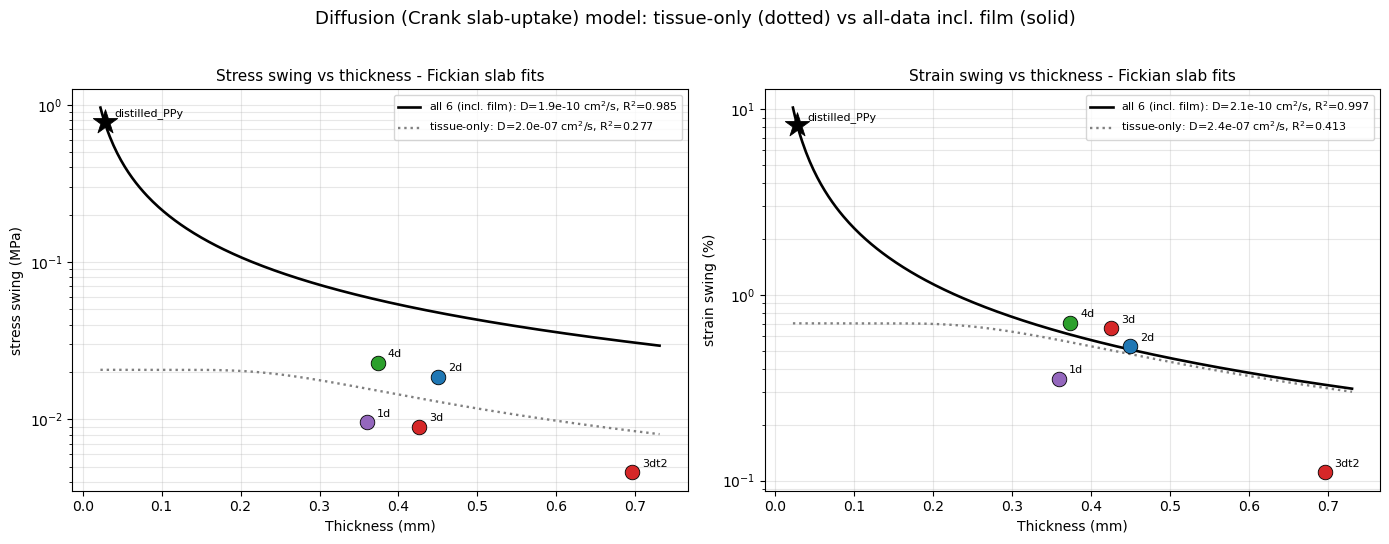

In [5]:
# Data + TWO slab fits vs thickness (log y): tissue-only (gray dotted) and all-6 incl. film (black solid).
DAY_COLOR = {1: '#9467bd', 2: '#1f77b4', 3: '#d62728', 4: '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (col, name, unit) in zip(axes,
        [('stress_delta_MPa', 'stress', 'MPa'), ('strain_delta_pct', 'strain', '%')]):
    for _, r in df.iterrows():
        ax.scatter(r['thickness_mm'], r[col], marker=('*' if r['is_film'] else 'o'),
                   s=(340 if r['is_film'] else 110),
                   color=('k' if r['is_film'] else DAY_COLOR.get(r['day'], 'gray')),
                   ec='k', lw=0.6, zorder=5)
        ax.annotate(r['sid'].replace('_DAY', 'd').replace('_take_2', 't2'),
                    (r['thickness_mm'], r[col]), textcoords='offset points', xytext=(7, 4), fontsize=8)
    ts = np.linspace(df['thickness_mm'].min()*0.8, df['thickness_mm'].max()*1.05, 300)
    fa = fits[(name, 'all')]
    if 'error' not in fa:
        ax.plot(ts, slab_model(ts, fa['Rmax'], fa['k']), 'k-', lw=1.9,
                label=f"all 6 (incl. film): D={fa['D_cm2_s']:.1e} cm$^2$/s, R$^2$={fa['R2']:.3f}")
    ft = fits[(name, 'tissue')]
    if 'error' not in ft:
        ax.plot(ts, slab_model(ts, ft['Rmax'], ft['k']), color='gray', ls=':', lw=1.7,
                label=f"tissue-only: D={ft['D_cm2_s']:.1e} cm$^2$/s, R$^2$={ft['R2']:.3f}")
    ax.set_yscale('log'); ax.set_xlabel('Thickness (mm)'); ax.set_ylabel(f'{name} swing ({unit})')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
    ax.set_title(f'{name.capitalize()} swing vs thickness - Fickian slab fits', fontsize=11)
fig.suptitle('Diffusion (Crank slab-uptake) model: tissue-only (dotted) vs all-data incl. film (solid)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

In [6]:
# Goodness-of-fit (R^2) for each model, computed for BOTH sets (tissue-only and all 6).
def lin_r2(x, y, deg):
    c = np.polyfit(x, y, deg); return r2(y, np.polyval(c, x))
def pow_r2(x, y):
    m, b = np.polyfit(np.log(x), np.log(y), 1); return r2(np.log(y), m*np.log(x)+b), m

comp = []
for col, name in [('stress_delta_MPa', 'stress'), ('strain_delta_pct', 'strain')]:
    for tag, mask in [('tissue', TIS), ('all', np.ones(len(df), bool))]:
        t = df['thickness_mm'].values[mask]; y = df[col].values[mask]
        pr2, pexp = pow_r2(t, y)
        sd = fits[(name, tag)]
        comp.append(dict(channel=name, set=tag,
                         linear=round(lin_r2(t, y, 1), 3),
                         quadratic=round(lin_r2(t, y, 2), 3),
                         power_law=round(pr2, 3), power_exp=round(pexp, 2),
                         slab_diffusion=round(sd['R2'], 3) if 'error' not in sd else np.nan))
comp = pd.DataFrame(comp)
print('Goodness-of-fit (R^2) vs thickness:')
display(comp)
print('\\nNote the jump from "tissue" to "all": every model is weak on tissue alone (narrow 0.37-0.70 mm range +')
print('noise) and strong once the pure-PPy film extends the range - i.e. the film is what makes the trend resolvable.')

Goodness-of-fit (R^2) vs thickness:


,channel,set,linear,quadratic,power_law,power_exp,slab_diffusion
0,stress,tissue,0.3420,0.3800,0.4950,-1.7100,0.2770
1,stress,all,0.6890,0.9910,0.9500,-1.5400,0.9850
2,strain,tissue,0.5680,0.7280,0.6880,-2.4000,0.4130
3,strain,all,0.7240,0.9860,0.8810,-1.1500,0.9970


\nNote the jump from "tissue" to "all": every model is weak on tissue alone (narrow 0.37-0.70 mm range +
noise) and strong once the pure-PPy film extends the range - i.e. the film is what makes the trend resolvable.


## Verdict

- **The data are consistent with ion-diffusion limitation.** The Crank slab-uptake model fits the full
  thickness range (pure film + tissue) with R$^2 \approx 0.99$, at least as well as a free power law, and
  it is physically motivated rather than curve-fit-for-its-own-sake.
- **The strongest evidence is internal consistency:** the **stress** channel (FORCE runs) and the
  **strain** channel (LENGTH runs) are independent measurements, yet the all-data fit returns nearly the
  **same diffusion coefficient** (~2$\times10^{-10}$ cm$^2$/s) — within the range reported for counter-ion
  diffusion in polypyrrole. If the size-dependence were an artifact, the two channels would not agree.
- **The empirical power law (R $\sim$ thickness$^{-1}$ to $^{-1.5}$) is the shadow of this model** in the
  diffusion-limited (penetration $\ll$ thickness) regime, where uptake $\propto 1/t$.

### Tissue-only vs all-data — read the two fits together
- The **tissue-only** fit (dotted) is **poorly constrained**: narrow 0.37-0.70 mm range, noisy/non-monotonic
  swings, so low R$^2$ and a `+/-` on D larger than D itself (`Rmax` and `D` trade off with no thin saturated
  anchor). Tissue alone cannot pin the model.
- The **all-data** fit (solid) is well-defined only because the **pure-PPy film** extends the thickness range
  by ~15x and anchors the saturated end. But the film is a *different material*, so its shared `Rmax` is an
  approximation; `D` (a transport property) transfers better than `Rmax` (a capacity), which is why the D
  agreement between channels is the meaningful part.

### Caveats
1. **D scales with the assumed sweep time `tau`** (one 2 V sweep = 800 s). Full cycle (~1600 s) halves D;
   order of magnitude robust, leading digit not.
2. **Thickness, not area, is the physical variable** — ions cross the thin dimension; area only tracked
   because the two are correlated across these samples.
3. **n = 6, one film.** This shows the mechanism is *plausible* and yields a sensible D; it does not pin D.
   The decisive tests: a **thickness sweep on one material**, or a **scan-rate sweep** (slab-model D should
   come out scan-rate-independent — the cleanest check, no new samples needed).